In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
from pathlib import Path
zip_path = "/content/drive/MyDrive/early-fire-detection/zippy/data.zip"
!unzip -o -q {zip_path} -d /

In [3]:
import sys
from pathlib import Path
PROJECT_ROOT = Path("/content/drive/MyDrive/early-fire-detection")
sys.path.insert(0, str(PROJECT_ROOT))

In [4]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision.models.detection import (
    fasterrcnn_resnet50_fpn_v2,
    FasterRCNN_ResNet50_FPN_V2_Weights,
)
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

In [5]:
from helpers.utils import set_seed, make_run_dir, load_checkpoint, train_detection_run, save_run_config
from helpers.datahelperrr import FireDataset, collate_fn, evaluate_map

In [6]:
DATA_DIR = Path("/data")
RUNS = PROJECT_ROOT / "models" / "runs"
NUM_CLASSES = 3  # background=0, fire=1, smoke=2
set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [7]:
def build_fasterrcnn(num_classes=NUM_CLASSES, trainable_backbone_layers=3):
    weights = FasterRCNN_ResNet50_FPN_V2_Weights.COCO_V1
    model = fasterrcnn_resnet50_fpn_v2(weights=weights, trainable_backbone_layers=trainable_backbone_layers)
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    model.transform.min_size = (640,)
    model.transform.max_size = 640
    return model

In [8]:
train_ds = FireDataset(DATA_DIR / "train", augment=True)
val_ds = FireDataset(DATA_DIR / "val", augment=False)
train_loader = DataLoader(train_ds, batch_size=8, shuffle=True, collate_fn=collate_fn, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=8, shuffle=False, collate_fn=collate_fn, num_workers=4, pin_memory=True)

In [ ]:
lr_sweep = [0.001, 0.005, 0.01, 0.02]
results = []

for lr in lr_sweep:
    lr_tag = str(lr).replace(".", "")
    set_seed(42)
    model = build_fasterrcnn(num_classes=NUM_CLASSES, trainable_backbone_layers=3).to(device)
    model.to(device)
    load_checkpoint(RUNS / "fasterrcnn_v2_freeze_head" / "weights" / "best.pt", model)

    params = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.SGD(params, lr=lr, momentum=0.9, weight_decay=0.0005)
    run_dir = make_run_dir(RUNS, f"fasterrcnn_v2_unfreeze_l3_lr{lr_tag}_hyper")
    save_run_config(run_dir, {
        "lr": lr,
        "epochs": 10,
        "trainable_backbone_layers": 3,
        "optimizer": "SGD",
        "momentum": 0.9,
        "weight_decay": 0.0005,
        "batch_size": 8,
        "augment": True,
        "seed": 42,
        "start_checkpoint": "fasterrcnn_v2_freeze_head/weights/best.pt",
    })

    try: 
        train_detection_run(model, optimizer, train_loader, val_loader, device, run_dir, epochs=10)
        df = pd.read_csv(run_dir / "metrics.csv")
        best = df.loc[df["map50"].idxmax()]
        results.append({
            "run": run_dir.name,
            "lr": lr,
            "best_epoch": int(best["epoch"]),
            "map50": float(best["map50"]),
            "map75": float(best["map75"]),
            "ap50_fire": float(best["ap50_fire"]),
            "ap50_smoke": float(best["ap50_smoke"]),
            "val_total": float(best["val_total"]),
        })
    except Exception as e:
        print(f"Training failed for {lr}: {e}")

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth


100%|██████████| 167M/167M [00:00<00:00, 239MB/s] 


Epoch 1, Step 200, Loss: 0.136032657250762
Epoch 1, Step 400, Loss: 0.13698656703345477
AP@0.50  fire: 0.918
AP@0.50  smoke: 0.859
mAP@0.50: 0.889
AP@0.75  fire: 0.651
AP@0.75  smoke: 0.383
mAP@0.75: 0.517
Epoch 1: val_total 0.13265074613544106, map50 0.8887831870738232, map75 0.5167389454299297, 178.5014410018921s
Epoch 2, Step 200, Loss: 0.12126646714285017
Epoch 2, Step 400, Loss: 0.11944783383049071
AP@0.50  fire: 0.947
AP@0.50  smoke: 0.882
mAP@0.50: 0.914
AP@0.75  fire: 0.703
AP@0.75  smoke: 0.542
mAP@0.75: 0.623
Epoch 2: val_total 0.11944180585306846, map50 0.9140694917373997, map75 0.6229305174484168, 176.68602013587952s
Epoch 3, Step 200, Loss: 0.10831738835200667
Epoch 3, Step 400, Loss: 0.11021336353383958
AP@0.50  fire: 0.957
AP@0.50  smoke: 0.896
mAP@0.50: 0.926
AP@0.75  fire: 0.718
AP@0.75  smoke: 0.476
mAP@0.75: 0.597
Epoch 3: val_total 0.11161745787581052, map50 0.9262171260294255, map75 0.5970488682213808, 177.0595109462738s
Epoch 4, Step 200, Loss: 0.10519118815660476

In [22]:
LR_RUNS = [
    "fasterrcnn_v2_unfreeze_l3_lr0001_hyper",
    "fasterrcnn_v2_unfreeze_l3_lr0005_hyper",
    "fasterrcnn_v2_unfreeze_l3_lr001_hyper",
    "fasterrcnn_v2_unfreeze_l3_lr002_hyper",
]

rows = []
for name in LR_RUNS:
    tag = name.split("_lr")[1].replace("_hyper", "")
    lr = float("0." + tag[1:])
    df = pd.read_csv(RUNS / name / "metrics.csv")
    best = df.loc[df["map50"].idxmax()]
    rows.append({
        "run": name,
        "lr": lr,
        "best_epoch": int(best["epoch"]),
        "map50": float(best["map50"]),
        "map75": float(best["map75"]),
        "ap50_fire": float(best["ap50_fire"]),
        "ap50_smoke": float(best["ap50_smoke"]),
        "val_total": float(best["val_total"]),
    })

summary = pd.DataFrame(rows).sort_values("lr")
summary.to_csv(RUNS / "lr_sweep_e10_summary.csv", index=False)
summary

,run,lr,best_epoch,map50,map75,ap50_fire,ap50_smoke,val_total
0,fasterrcnn_v2_unfreeze_l3_lr0001_hyper,0.001,10,0.939505,0.661770,0.962313,0.916698,0.105472
1,fasterrcnn_v2_unfreeze_l3_lr0005_hyper,0.005,9,0.947919,0.700972,0.966278,0.929559,0.102411
2,fasterrcnn_v2_unfreeze_l3_lr001_hyper,0.010,10,0.941196,0.664190,0.960229,0.922162,0.104529
3,fasterrcnn_v2_unfreeze_l3_lr002_hyper,0.020,9,0.933611,0.628419,0.956832,0.910390,0.112497


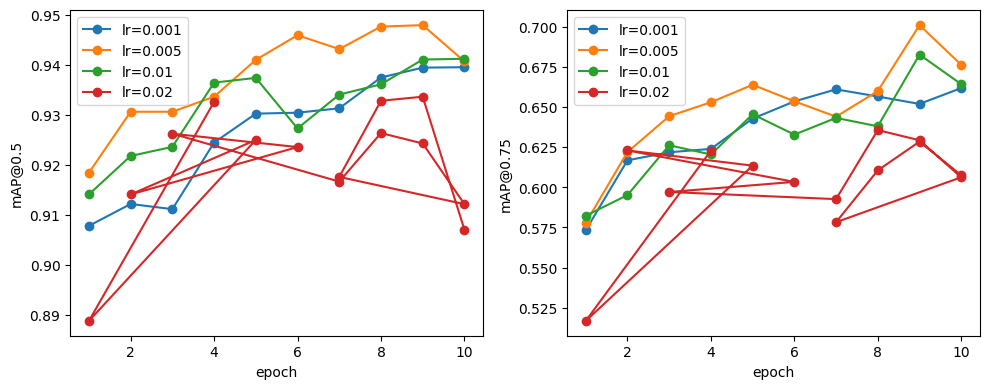

In [23]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
for name in LR_RUNS:
    df = pd.read_csv(RUNS / name / "metrics.csv")
    tag = name.split("_lr")[1].replace("_hyper", "")
    lr = float("0." + tag[1:])
    ax[0].plot(df["epoch"], df["map50"], marker="o", label=f"lr={lr}")
    ax[1].plot(df["epoch"], df["map75"], marker="o", label=f"lr={lr}")
ax[0].set_xlabel("epoch")
ax[0].set_ylabel("mAP@0.5")
ax[0].legend()
ax[1].set_xlabel("epoch")
ax[1].set_ylabel("mAP@0.75")
ax[1].legend()
plt.tight_layout()
plt.show()

In [9]:
WD_RUNS = [
    {"name": "wd0", "weight_decay": 0.0},
    {"name": "wd1e4", "weight_decay": 1e-4},
    {"name": "wd1e3", "weight_decay": 1e-3},
]

results = []
for spec in WD_RUNS:
    set_seed(42)
    model = build_fasterrcnn(trainable_backbone_layers=3)
    model.to(device)
    load_checkpoint(RUNS / "fasterrcnn_v2_freeze_head" / "weights" / "best.pt", model)
    params = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.SGD(
        params, lr=0.005, momentum=0.9, weight_decay=spec["weight_decay"],
    )
    run_dir = make_run_dir(RUNS, f"fasterrcnn_v2_unfreeze_l3_{spec['name']}_hyper")
    save_run_config(run_dir, {
        "lr": 0.005,
        "weight_decay": spec["weight_decay"],
        "epochs": 10,
        "schedule": "constant",
        "trainable_backbone_layers": 3,
        "optimizer": "SGD",
        "start_checkpoint": "fasterrcnn_v2_freeze_head/weights/best.pt",
    })
    try:
        train_detection_run(
            model, optimizer, train_loader, val_loader, device, run_dir, epochs=10,
        )
        df = pd.read_csv(run_dir / "metrics.csv")
        best = df.loc[df["map50"].idxmax()]
        results.append({
            "run": run_dir.name,
            "weight_decay": spec["weight_decay"],
            "best_epoch": int(best["epoch"]),
            "map50": float(best["map50"]),
            "map75": float(best["map75"]),
            "val_total": float(best["val_total"]),
        })
    except Exception as e:
        print(f"Failed: {spec['name']}: {e}")

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth


100%|██████████| 167M/167M [00:00<00:00, 239MB/s] 


Epoch 1, Step 200, Loss: 0.11334266209974884
Epoch 1, Step 400, Loss: 0.11431341486051678
AP@0.50  fire: 0.956
AP@0.50  smoke: 0.880
mAP@0.50: 0.918
AP@0.75  fire: 0.732
AP@0.75  smoke: 0.481
mAP@0.75: 0.607
Epoch 1: val_total 0.11293337747820316, map50 0.9181967764486942, map75 0.6065311286284442, 179.6542317867279s
Epoch 2, Step 200, Loss: 0.10765774054452777
Epoch 2, Step 400, Loss: 0.10532564913854003
AP@0.50  fire: 0.959
AP@0.50  smoke: 0.888
mAP@0.50: 0.924
AP@0.75  fire: 0.693
AP@0.75  smoke: 0.540
mAP@0.75: 0.616
Epoch 2: val_total 0.11187194911705936, map50 0.9235420035010378, map75 0.6164824505831062, 175.55367803573608s
Epoch 3, Step 200, Loss: 0.09450807021930814
Epoch 3, Step 400, Loss: 0.0965494797937572
AP@0.50  fire: 0.966
AP@0.50  smoke: 0.900
mAP@0.50: 0.933
AP@0.75  fire: 0.763
AP@0.75  smoke: 0.549
mAP@0.75: 0.656
Epoch 3: val_total 0.1074063456817273, map50 0.9332957246743228, map75 0.6556347601583319, 176.10318112373352s
Epoch 4, Step 200, Loss: 0.0893355052545666

In [10]:
WD_NAMES = [
    ("fasterrcnn_v2_unfreeze_l3_wd0_hyper", 0.0),
    ("fasterrcnn_v2_unfreeze_l3_wd1e4_hyper", 1e-4),
    ("fasterrcnn_v2_unfreeze_l3_lr0005_hyper", 5e-4),
    ("fasterrcnn_v2_unfreeze_l3_wd1e3_hyper", 1e-3),
]
rows = []
for name, wd in WD_NAMES:
    df = pd.read_csv(RUNS / name / "metrics.csv")
    best = df.loc[df["map50"].idxmax()]
    rows.append({
        "run": name,
        "weight_decay": wd,
        "best_epoch": int(best["epoch"]),
        "map50": float(best["map50"]),
        "map75": float(best["map75"]),
        "val_total": float(best["val_total"]),
    })
pd.DataFrame(rows)

,run,weight_decay,best_epoch,map50,map75,val_total
0,fasterrcnn_v2_unfreeze_l3_wd0_hyper,0.0000,5,0.946533,0.689818,0.103037
1,fasterrcnn_v2_unfreeze_l3_wd1e4_hyper,0.0001,8,0.951420,0.655366,0.102877
2,fasterrcnn_v2_unfreeze_l3_lr0005_hyper,0.0005,9,0.947919,0.700972,0.102411
3,fasterrcnn_v2_unfreeze_l3_wd1e3_hyper,0.0010,9,0.948297,0.689591,0.101154


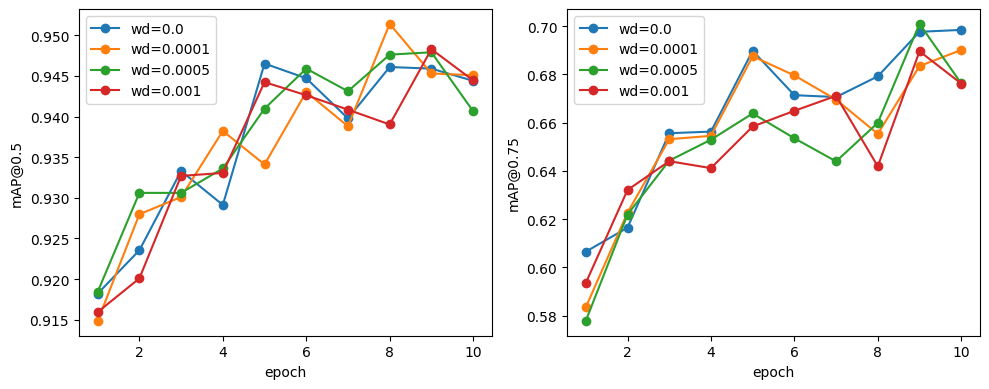

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
for name, wd in WD_NAMES:
    df = pd.read_csv(RUNS / name / "metrics.csv")
    label = f"wd={wd}"
    ax[0].plot(df["epoch"], df["map50"], marker="o", label=label)
    ax[1].plot(df["epoch"], df["map75"], marker="o", label=label)
ax[0].set_xlabel("epoch")
ax[0].set_ylabel("mAP@0.5")
ax[0].legend()
ax[1].set_xlabel("epoch")
ax[1].set_ylabel("mAP@0.75")
ax[1].legend()
plt.tight_layout()
plt.show()

In [12]:
LAYER_RUNS = [
    {"name": "l1", "layers": 1},
    {"name": "l2", "layers": 2},
    {"name": "l4", "layers": 4},
    {"name": "l5", "layers": 5},
]

results = []
for spec in LAYER_RUNS:
    set_seed(42)
    model = build_fasterrcnn(trainable_backbone_layers=spec["layers"])
    model.to(device)
    load_checkpoint(RUNS / "fasterrcnn_v2_freeze_head" / "weights" / "best.pt", model)

    params = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)
    run_dir = make_run_dir(RUNS, f"fasterrcnn_v2_unfreeze_{spec['name']}_hyper")
    save_run_config(run_dir, {
        "lr": 0.005,
        "weight_decay": 0.0005,
        "epochs": 10,
        "trainable_backbone_layers": spec["layers"],
        "optimizer": "SGD",
        "start_checkpoint": "fasterrcnn_v2_freeze_head/weights/best.pt",
    })

    try:
        train_detection_run(
            model, optimizer, train_loader, val_loader, device, run_dir, epochs=10,
        )
        df = pd.read_csv(run_dir / "metrics.csv")
        best = df.loc[df["map50"].idxmax()]
        results.append({
            "run": run_dir.name,
            "layers": spec["layers"],
            "best_epoch": int(best["epoch"]),
            "map50": float(best["map50"]),
            "map75": float(best["map75"]),
            "val_total": float(best["val_total"]),
        })
    except Exception as e:
        print(f"failed {spec['name']}: {e}")

Epoch 1, Step 200, Loss: 0.11270435193553567
Epoch 1, Step 400, Loss: 0.1135930703766644
AP@0.50  fire: 0.945
AP@0.50  smoke: 0.844
mAP@0.50: 0.895
AP@0.75  fire: 0.683
AP@0.75  smoke: 0.408
mAP@0.75: 0.545
Epoch 1: val_total 0.1186570448149567, map50 0.894510319744239, map75 0.5454213015400647, 164.61624002456665s
Epoch 2, Step 200, Loss: 0.11047425173223019
Epoch 2, Step 400, Loss: 0.10929089583456517
AP@0.50  fire: 0.949
AP@0.50  smoke: 0.846
mAP@0.50: 0.898
AP@0.75  fire: 0.683
AP@0.75  smoke: 0.474
mAP@0.75: 0.578
Epoch 2: val_total 0.11932287481756298, map50 0.897808084591867, map75 0.5782210988802087, 164.667582988739s
Epoch 3, Step 200, Loss: 0.10206847794353963
Epoch 3, Step 400, Loss: 0.10367836136370898
AP@0.50  fire: 0.954
AP@0.50  smoke: 0.869
mAP@0.50: 0.912
AP@0.75  fire: 0.723
AP@0.75  smoke: 0.484
mAP@0.75: 0.604
Epoch 3: val_total 0.11836053168206859, map50 0.9116308282216059, map75 0.6035549874738324, 165.1021375656128s
Epoch 4, Step 200, Loss: 0.09812003757804633
Ep

In [14]:
LAYER_NAMES = [
    ("fasterrcnn_v2_unfreeze_l1_hyper", 1),
    ("fasterrcnn_v2_unfreeze_l2_hyper", 2),
    ("fasterrcnn_v2_unfreeze_l3_lr0005_hyper", 3),
    ("fasterrcnn_v2_unfreeze_l4_hyper", 4),
    ("fasterrcnn_v2_unfreeze_l5_hyper", 5),
]

rows = []
for name, layers in LAYER_NAMES: 
    df = pd.read_csv(RUNS / name / "metrics.csv")
    best = df.loc[df["map50"].idxmax()]
    rows.append({
        "run": name,
        "layers": layers,
        "best_epoch": int(best["epoch"]),
        "map50": float(best["map50"]),
        "map75": float(best["map75"]),
        "val_total": float(best["val_total"]),
    })

In [15]:
pd.DataFrame(rows)

,run,layers,best_epoch,map50,map75,val_total
0,fasterrcnn_v2_unfreeze_l1_hyper,1,10,0.935434,0.642691,0.113192
1,fasterrcnn_v2_unfreeze_l2_hyper,2,9,0.942973,0.656577,0.108314
2,fasterrcnn_v2_unfreeze_l3_lr0005_hyper,3,9,0.947919,0.700972,0.102411
3,fasterrcnn_v2_unfreeze_l4_hyper,4,9,0.948366,0.685819,0.100443
4,fasterrcnn_v2_unfreeze_l5_hyper,5,8,0.952135,0.683765,0.101252


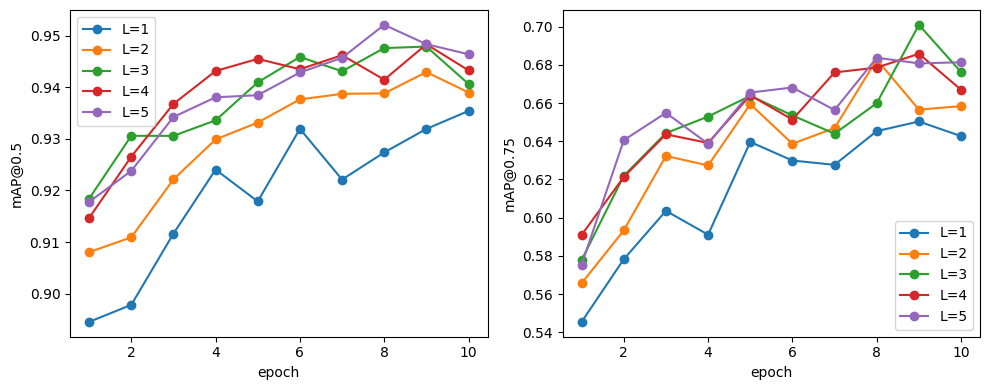

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
for name, layers in LAYER_NAMES:
    df = pd.read_csv(RUNS / name / "metrics.csv")
    ax[0].plot(df["epoch"], df["map50"], marker="o", label=f"L={layers}")
    ax[1].plot(df["epoch"], df["map75"], marker="o", label=f"L={layers}")
ax[0].set_xlabel("epoch"); ax[0].set_ylabel("mAP@0.5"); ax[0].legend()
ax[1].set_xlabel("epoch"); ax[1].set_ylabel("mAP@0.75"); ax[1].legend()
plt.tight_layout()
plt.show()